- **학습 목표**: precision·recall·F1·specificity를 라이브러리 없이 혼동행렬 숫자만으로 계산하고, 도메인에 따라 무엇을 우선해야 하는지 판단할 수 있다.

In [9]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

precision_sklearn: 0.7272727272727273
recall_sklearn: 0.6666666666666666
confusion_matrix_sklearn: [[40 12]
 [16 32]]
f1_sklearn: 0.6956521739130435


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


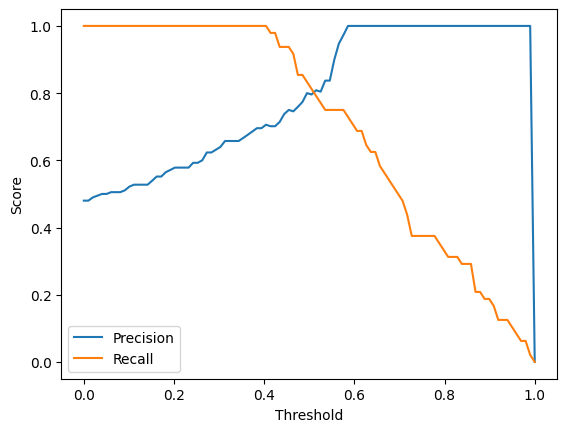

In [15]:
def metrics_from_confusion(tn, fp, fn, tp) -> dict:
  """
  요구사항:
  - sklearn.metrics의 precision_score 등을 쓰지 말고 정의식으로 직접 계산.
  - precision, recall(=TPR=sensitivity), specificity(=TNR), f1을 dict로 반환.
  - 분모가 0이 되는 경우를 어떻게 처리할지 스스로 결정할 것.
  - sklearn 함수 결과와 비교해 일치하는지 검증할 것.
  """
  precision = tp / (tp + fp) if tp+fp > 0 else 0
  recall = tp / (tp + fn) if tp+fn > 0 else 0
  specificity = tn / (tn + fp) if tn+fp > 0 else 0
  f1 = 2*precision*recall/(precision+recall) if precision+recall > 0 else 0
  result = {
      'precision' : precision,
      'recall' : recall,
      'specificity' : specificity,
      "f1" : f1
  }
  precision_sklearn = precision_score(y_true, y_pred)
  recall_sklearn = recall_score(y_true, y_pred)
  confusion_matrix_sklearn = confusion_matrix(y_true, y_pred)
  f1_sklearn = f1_score(y_true, y_pred)
  return result


def threshold_sweep(y_true, y_proba, thresholds=(0.3, 0.5, 0.7)):
  """
  요구사항:
  - 각 임계값에서 예측 라벨을 만들고 위 지표들을 계산해 표로 출력한다.
  - 임계값이 올라갈수록 precision과 recall이 각각 어떻게 움직이는지 관찰.
  """
  y_pred = np.where(y_proba > thresholds, 1, 0)
  precision = precision_score(y_true, y_pred)
  recall = recall_score(y_true, y_pred)
  return precision, recall

# 데이터 개수 설정
n_samples = 100

# 실제값 (0 또는 1을 임의로 생성)
y_true = np.random.choice([0, 1], size=n_samples, p=[0.5, 0.5])

# 예측값 (실제값의 80%는 맞추고, 20%는 틀리도록 확률적 생성)
# 모델의 성능(정확도 약 80%)을 흉내 낸 예시입니다.
y_pred = np.array([t if np.random.rand() < 0.8 else 1 - t for t in y_true])
precision_sklearn = precision_score(y_true, y_pred)
recall_sklearn = recall_score(y_true, y_pred)
confusion_matrix_sklearn = confusion_matrix(y_true, y_pred)
f1_sklearn = f1_score(y_true, y_pred)
print(f"precision_sklearn: {precision_sklearn}")
print(f"recall_sklearn: {recall_sklearn}")
print(f"confusion_matrix_sklearn: {confusion_matrix_sklearn}")
print(f"f1_sklearn: {f1_sklearn}")
tp = confusion_matrix_sklearn[1,1]
fp = confusion_matrix_sklearn[0,1]
fn = confusion_matrix_sklearn[1,0]
tn = confusion_matrix_sklearn[0,0]
metrics_from_confusion(tp, fp, fn, tp)

y_proba = np.where(
    y_true == 1,
    np.random.uniform(0.4, 1.0, size=n_samples),
    np.random.uniform(0.0, 0.6, size=n_samples)
)
thresholds = np.linspace(0, 1, 100)
precisions = []
recalls = []

for threshold in thresholds:
  precision, recall = threshold_sweep(y_true, y_proba, threshold)
  precisions.append(precision)
  recalls.append(recall)

plt.figure()
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.show()

- **학습 목표**: 로지스틱 회귀가 "선형" 분류기라는 말의 의미를 그림으로 확인한다. 동시에 W1의 PCA가 여기서 도구로 쓰이는 것을 경험한다.

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


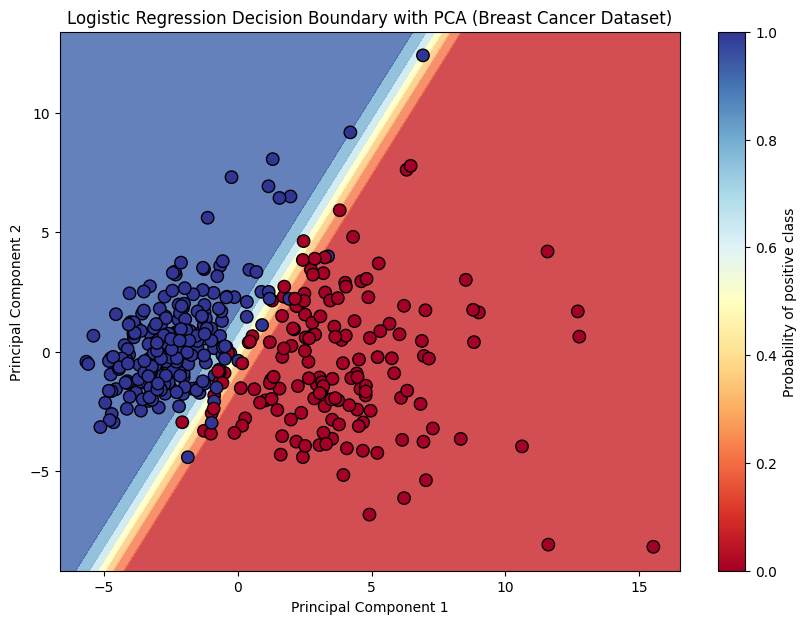

In [18]:
def plot_decision_boundary():
  """
  요구사항:
  - breast_cancer를 표준화한 뒤 PCA로 2차원 축소 (W1/W2에서 만든 SimplePCA를
    써도 되고 sklearn PCA를 써도 됨 — 직접 만든 걸 쓰면 더 좋음).
  - 2차원 데이터로 LogisticRegression 학습.
  - meshgrid로 평면 전체의 P(양성)을 계산해 contourf로 확률 등고선을 그린다.
  - 실제 샘플을 클래스별 색으로 산점도로 겹쳐 그린다.
  - 'week03/decision_boundary.png'로 저장.
  """
  data = load_breast_cancer()
  X, y = data.data, data.target
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3)
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)
  pca =PCA(n_components=2)
  X_train_pca = pca.fit_transform(X_train_scaled)
  X_test_pca = pca.transform(X_test_scaled)
  log_reg = LogisticRegression()
  log_reg.fit(X_train_pca, y_train)

  # Create meshgrid for plotting decision boundary
  x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
  y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                       np.arange(y_min, y_max, 0.02))

  # Predict probabilities for each point in the meshgrid
  Z = log_reg.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
  Z = Z.reshape(xx.shape)

  plt.figure(figsize=(10, 7))
  # Plot the contourf with probabilities
  plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

  # Plot actual data points
  plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=plt.cm.RdYlBu, edgecolor='k', s=80)
  plt.xlabel('Principal Component 1')
  plt.ylabel('Principal Component 2')
  plt.title('Logistic Regression Decision Boundary with PCA (Breast Cancer Dataset)')
  plt.colorbar(label='Probability of positive class')

  # Create the directory if it doesn't exist
  import os
  output_dir = 'week03'
  if not os.path.exists(output_dir):
      os.makedirs(output_dir)

  plt.savefig(os.path.join(output_dir, 'decision_boundary.png'))
  plt.show()

# Call the function to generate and save the plot
plot_decision_boundary()